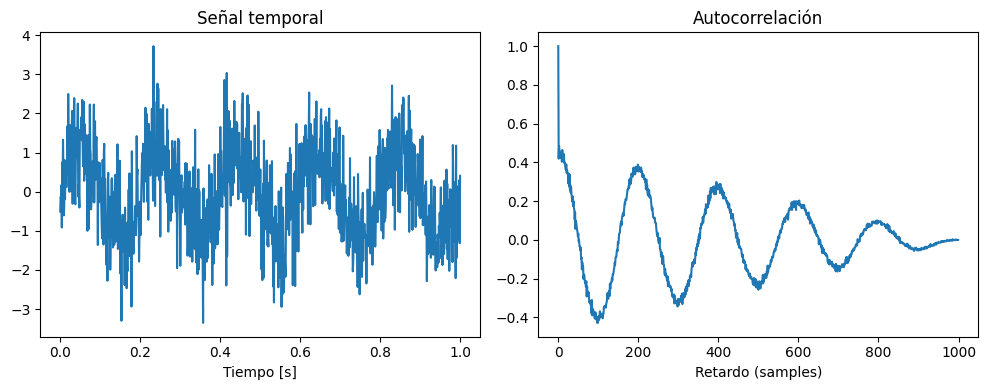

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs = 1000          # Hz
t = np.arange(0, 1, 1/fs)
f0 = 5             # Hz

# Señal senoidal + ruido
x = np.sin(2*np.pi*f0*t) + 0.8*np.random.randn(len(t))

# Autocorrelación
acf = np.correlate(x, x, mode='full')
acf = acf[len(acf)//2:]   # solo retardos positivos
acf /= acf[0]             # normalización

# Gráficos
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, x)
plt.title("Señal temporal")
plt.xlabel("Tiempo [s]")

plt.subplot(1,2,2)
plt.plot(acf)
plt.title("Autocorrelación")
plt.xlabel("Retardo (samples)")

plt.tight_layout()
plt.show()


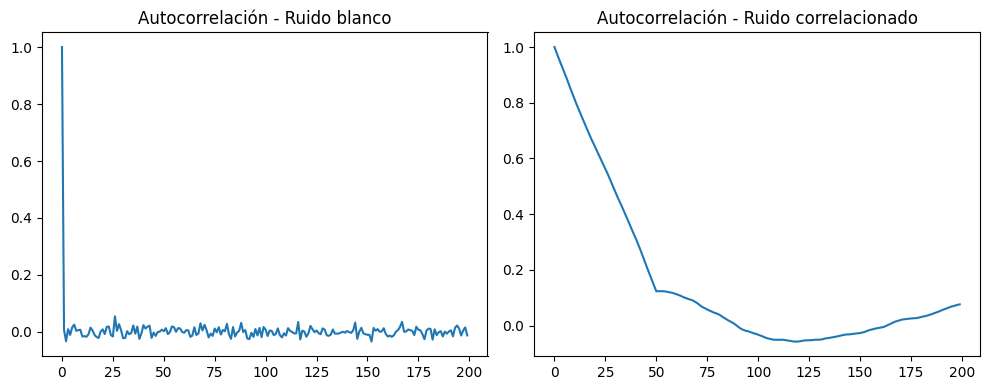

In [ ]:
# Ruido blanco
white = np.random.randn(5000)

# Ruido correlacionado (filtrado)
corr = np.convolve(white, np.ones(50)/50, mode='same')

# Autocorrelaciones
acf_white = np.correlate(white, white, mode='full')
acf_corr = np.correlate(corr, corr, mode='full')

acf_white = acf_white[len(acf_white)//2:] / acf_white[len(acf_white)//2]
acf_corr = acf_corr[len(acf_corr)//2:] / acf_corr[len(acf_corr)//2]

# Gráficos
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(acf_white[:200])
plt.title("Autocorrelación - Ruido blanco")

plt.subplot(1,2,2)
plt.plot(acf_corr[:200])
plt.title("Autocorrelación - Ruido correlacionado")

plt.tight_layout()
plt.show()


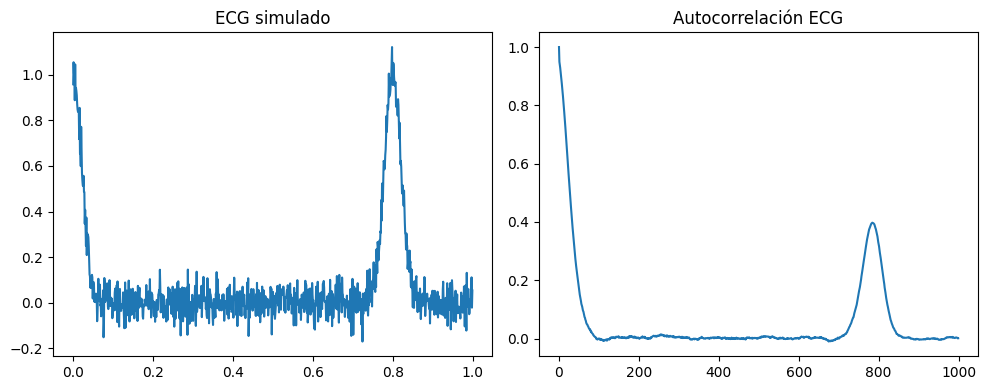

In [ ]:
# ECG artificial simple
rr = 0.8
beats = np.zeros_like(t)
for k in np.arange(0, t[-1], rr):
    beats += np.exp(-((t-k)/0.03)**2)

ecg = beats + 0.05*np.random.randn(len(t))

acf_ecg = np.correlate(ecg, ecg, mode='full')
acf_ecg = acf_ecg[len(acf_ecg)//2:]
acf_ecg /= acf_ecg[0]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t, ecg)
plt.title("ECG simulado")

plt.subplot(1,2,2)
plt.plot(acf_ecg[:2000])
plt.title("Autocorrelación ECG")

plt.tight_layout()
plt.show()
